# Objetivo

Na etapa de modelagem estatística, verificou-se que o problema apresenta relações não lineares e possíveis interações entre segmentos de clientes que não foram plenamente representadas pela Regressão Logística. Embora o modelo tenha alcançado acurácia aproximada de 84%, apresentou baixo recall para a classe churn, deixando de identificar uma parcela relevante dos clientes que efetivamente abandonaram o banco.

Diante disso, este notebook tem como objetivo avaliar algoritmos de Machine Learning capazes de representar relações não lineares e melhorar a identificação da classe churn. A comparação dará atenção especial ao recall, ao F1-score e à PR-AUC, buscando modelos que apresentem melhor capacidade de discriminar clientes em risco sem produzir quantidade excessiva de falsos positivos.

Na etapa de otimização, os hiperparâmetros serão selecionados com base na PR-AUC, por se tratar de uma métrica independente de um único limiar de classificação e adequada à avaliação da classe minoritária. Posteriormente, o limiar de decisão poderá ser ajustado para privilegiar o recall e reduzir o número de falsos negativos.

# Construção e seleção dos modelos

## Preparação

In [1]:
import hashlib
from datetime import datetime, timezone
import json
import math
import platform
from pathlib import Path
from urllib.robotparser import normalize
import sklearn

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve, fbeta_score, make_scorer,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.validation import check_is_fitted

RANDOM_STATE = 42

In [2]:
df = pd.read_csv('../data/raw/Churn_Modelling.csv', sep=',', na_values=[''], quotechar='"')

Remoção dos atributos que apresentam identificadores e não representam atributo comportamentais dos clientes.

In [3]:
df.drop(columns=['CustomerId', 'RowNumber', 'Surname'], inplace=True)

In [4]:
y = df["Exited"]

Tratamento do Complete Separation: clientes com 3+ produtos apresentam comportamento bastante diferentes do restante do conjunto de dados

In [5]:
df["ProductsGroup"] = df["NumOfProducts"].replace({
    1: "1",
    2: "2",
    3: "3+",
    4: "3+",
})

df["ProductsGroup"] = pd.Categorical(df["ProductsGroup"], categories=["1", "2", "3+"])

X = df.drop(columns=["Exited"])

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [7]:

baseline_models = {
    "Regressão Logística": LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="lbfgs",
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
}

machine_learning_models = {
    "KNN": KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        metric="minkowski",
        p=2,
        n_jobs=-1,
    ),

    "SVM RBF": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        class_weight=None,
        random_state=RANDOM_STATE,
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion="gini",
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight=None,
        random_state=RANDOM_STATE,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        criterion="gini",
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        bootstrap=True,
        class_weight=None,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=20,
        min_samples_leaf=10,
        subsample=0.8,
        random_state=RANDOM_STATE,
    ),
}

In [8]:

numeric_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
]

categorical_features = [
    "Geography",
    "Gender",
    "ProductsGroup",
]

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop=None,
                sparse_output=False,
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop=None,
                sparse_output=False,
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
)

## Comparação dos modelos por validação cruzada estratificada


In [9]:
scaled_model_names = {
    "Regressão Logística",
    "KNN",
    "SVM RBF",
}

all_models = {
    **baseline_models,
    **machine_learning_models,
}

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

resultados_cv = []

for model_name, estimator in all_models.items():
    preprocessor = (
        preprocessor_scaled
        if model_name in scaled_model_names
        else preprocessor_tree
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        Y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
    )

    resultados_cv.append({
        "Modelo": model_name,
        "Accuracy média": scores["test_accuracy"].mean(),
        "Balanced Accuracy média":
            scores["test_balanced_accuracy"].mean(),
        "Precision média": scores["test_precision"].mean(),
        "Recall médio": scores["test_recall"].mean(),
        "F1 médio": scores["test_f1"].mean(),
        "ROC-AUC médio": scores["test_roc_auc"].mean(),
        "PR-AUC médio": scores["test_pr_auc"].mean(),
        "Recall desvio-padrão": scores["test_recall"].std(),
        "F1 desvio-padrão": scores["test_f1"].std(),
        "PR-AUC desvio-padrão": scores["test_pr_auc"].std(),
    })

resultados_df = (
    pd.DataFrame(resultados_cv)
    .set_index("Modelo")
    .sort_values("Recall médio", ascending=False)
)

resultados_df

/home/rodrigo-emygdio/Estudos/Faculdade/PUC/IA-MACHINE-LEARNING/Projetos_Finais/ML_E_Modelagem_Preditiva/bank-churn-analytics/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/rodrigo-emygdio/Estudos/Faculdade/PUC/IA-MACHINE-LEARNING/Projetos_Finais/ML_E_Modelagem_Preditiva/bank-churn-analytics/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of pe

,Accuracy média,Balanced Accuracy média,Precision média,Recall médio,F1 médio,ROC-AUC médio,PR-AUC médio,Recall desvio-padrão,F1 desvio-padrão,PR-AUC desvio-padrão
Modelo,,,,,,,,,,
Gradient Boosting,0.863500,0.717301,0.769136,0.470552,0.583541,0.865549,0.696938,0.037297,0.036425,0.015842
Random Forest,0.861625,0.709048,0.775080,0.451534,0.570511,0.858446,0.683856,0.023232,0.023341,0.015734
Decision Tree,0.856375,0.699132,0.757847,0.433742,0.551609,0.835465,0.632119,0.020030,0.022597,0.018476
SVM RBF,0.854250,0.675885,0.805313,0.374847,0.511176,0.826011,0.657694,0.029062,0.029649,0.026549
Regressão Logística,0.840000,0.666024,0.702162,0.372393,0.486479,0.831286,0.614766,0.021481,0.020838,0.016904
KNN,0.836250,0.640843,0.730884,0.311043,0.436319,0.813549,0.588226,0.016301,0.022687,0.043604


A validação cruzada estratificada confirmou o Gradient Boosting como o modelo de melhor desempenho global, apresentando os maiores valores médios de recall, F1-score, ROC-AUC e PR-AUC. O Random Forest apresentou desempenho próximo e maior estabilidade no recall. Esses resultados justificam a seleção dos modelos de ensemble para a etapa de otimização de hiperparâmetros.

Os resultados obtidos por validação cruzada mostraram comportamento consistente entre os diferentes algoritmos avaliados. O Gradient Boosting apresentou o melhor desempenho em todas as principais métricas relacionadas à identificação da classe minoritária, alcançando o maior recall médio (47%), F1-score (0,584) e PR-AUC (0,697).

O Random Forest apresentou desempenho muito próximo, confirmando a capacidade dos métodos baseados em árvores de capturar relações não lineares e interações entre variáveis identificadas durante a etapa de modelagem estatística. Em contraste, modelos lineares, como a Regressão Logística, e métodos baseados em distância, como o KNN, apresentaram desempenho inferior na identificação da classe de churn.

O SVM apesar de recall médio inferior, teve um PR-AUC superior ao da Decision Tree e apresenta uma capacidade de ranqueamento da classe churn melhor.

Esses resultados corroboram os achados obtidos durante a análise estatística, que indicaram a presença de relações não lineares, segmentos específicos de clientes e padrões de interação não explicitamente modelados pela regressão logística. Os modelos baseados em árvores mostraram-se mais adequados para representar essa estrutura dos dados.

Embora o Gradient Boosting tenha apresentado o melhor desempenho, o recall médio permaneceu inferior a 50%, indicando que uma parcela considerável dos clientes que realizam churn continua não sendo identificada. Esse comportamento é consistente com a análise dos resíduos realizada anteriormente, sugerindo que parte desse erro decorre da ausência de variáveis comportamentais relevantes no conjunto de dados, e não apenas da escolha do algoritmo.

## Seleção dos modelos para otimização

Foram selecionados para otimização o Gradient Boosting e o Random Forest, por apresentarem os melhores resultados globais; a Decision Tree, por alcançar o terceiro maior recall médio e permitir avaliar isoladamente o comportamento da estrutura que fundamenta os modelos de ensemble; e o SVM RBF, por apresentar PR-AUC superior à árvore individual, apesar do menor recall no limiar padrão. Dessa forma, a seleção considerou tanto o desempenho observado quanto a diversidade de funcionamento dos algoritmos.

In [10]:
models_for_optimization = {
    "Gradient Boosting": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            (
                "model",
                GradientBoostingClassifier(
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            (
                "model",
                RandomForestClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),

    "Decision Tree": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            (
                "model",
                DecisionTreeClassifier(
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),

    "SVM RBF": Pipeline(
        steps=[
            ("preprocessor", preprocessor_scaled),
            (
                "model",
                SVC(
                    kernel="rbf",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

# Otimização dos hiperparâmetros

## Otimização com GridSearchCV

Busca de hiperparâmetros nos modelos mais promissores para verificar se há ganho real em relação ao baseline.

In [11]:
param_grids = {
    "Gradient Boosting": {
        "model__n_estimators": [100, 150, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3],
        "model__min_samples_leaf": [5, 10],
        "model__subsample": [0.8, 1.0],
    },

    "Random Forest": {
        "model__n_estimators": [200, 300],
        "model__max_depth": [None, 8],
        "model__min_samples_split": [5, 10],
        "model__min_samples_leaf": [2, 4],
        "model__max_features": ["sqrt"],
        "model__class_weight": [None, "balanced"],
    },

    "Decision Tree": {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [3, 5, 7, None],
        "model__min_samples_split": [10, 20, 40],
        "model__min_samples_leaf": [5, 10, 20],
        "model__class_weight": [None, "balanced"],
    },

    "SVM RBF": {
        "model__C": [0.5, 1.0, 2.0],
        "model__gamma": ["scale", 0.01, 0.1],
        "model__class_weight": [None, "balanced"],
    },
}

scoring_grid_search = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

refit="pr_auc"



In [12]:
grid_searches = {}
best_models = {}
grid_search_summary = []
grid_search_results = {}

for model_name, pipeline in models_for_optimization.items():

    print(f"Executando GridSearchCV para: {model_name}")

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        scoring=scoring,
        refit=refit,
        cv=cv,
        n_jobs=-1,
        return_train_score=True,
        error_score="raise",
    )

    grid_search.fit(X_train, Y_train)

    # Objeto completo do GridSearch
    grid_searches[model_name] = grid_search

    # Melhor pipeline, já treinado em todo o conjunto de treino
    best_models[model_name] = grid_search.best_estimator_

    # Resultados completos de todas as combinações
    grid_search_results[model_name] = pd.DataFrame(
        grid_search.cv_results_
    )

    # Índice da melhor configuração segundo a métrica de refit
    best_index = grid_search.best_index_

    # Resumo da melhor configuração
    grid_search_summary.append({
        "Model": model_name,
        "Best Parameters": grid_search.best_params_,

        "Train PR-AUC": (
            grid_search.cv_results_["mean_train_pr_auc"][best_index]
        ),
        "CV PR-AUC": (
            grid_search.cv_results_["mean_test_pr_auc"][best_index]
        ),
        "CV PR-AUC Std": (
            grid_search.cv_results_["std_test_pr_auc"][best_index]
        ),

        "CV Recall": (
            grid_search.cv_results_["mean_test_recall"][best_index]
        ),
        "CV Recall Std": (
            grid_search.cv_results_["std_test_recall"][best_index]
        ),

        "CV Precision": (
            grid_search.cv_results_["mean_test_precision"][best_index]
        ),

        "CV F1": (
            grid_search.cv_results_["mean_test_f1"][best_index]
        ),

        "CV ROC-AUC": (
            grid_search.cv_results_["mean_test_roc_auc"][best_index]
        ),

        "CV Balanced Accuracy": (
            grid_search.cv_results_[
                "mean_test_balanced_accuracy"
            ][best_index]
        ),

        "CV Accuracy": (
            grid_search.cv_results_["mean_test_accuracy"][best_index]
        ),

        "PR-AUC Train-CV Gap": (
            grid_search.cv_results_["mean_train_pr_auc"][best_index]
            - grid_search.cv_results_["mean_test_pr_auc"][best_index]
        ),
    })

    print(
        f"Melhor PR-AUC: {grid_search.best_score_:.4f}"
    )
    print(
        f"Melhores parâmetros: {grid_search.best_params_}"
    )
    print("-" * 80)

Executando GridSearchCV para: Gradient Boosting
Melhor PR-AUC: 0.6988
Melhores parâmetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 10, 'model__n_estimators': 200, 'model__subsample': 0.8}
--------------------------------------------------------------------------------
Executando GridSearchCV para: Random Forest
Melhor PR-AUC: 0.6856
Melhores parâmetros: {'model__class_weight': None, 'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 300}
--------------------------------------------------------------------------------
Executando GridSearchCV para: Decision Tree
Melhor PR-AUC: 0.6443
Melhores parâmetros: {'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_leaf': 20, 'model__min_samples_split': 10}
--------------------------------------------------------------------------------
Executando GridSearchCV par

In [13]:
grid_search_summary_df = (
    pd.DataFrame(grid_search_summary)
    .sort_values(
        by="CV PR-AUC",
        ascending=False,
    )
    .reset_index(drop=True)
)
grid_search_summary_df

,Model,Best Parameters,Train PR-AUC,CV PR-AUC,CV PR-AUC Std,CV Recall,CV Recall Std,CV Precision,CV F1,CV ROC-AUC,CV Balanced Accuracy,CV Accuracy,PR-AUC Train-CV Gap
0,Gradient Boosting,"{'model__learning_rate': 0.05, 'model__max_dep...",0.756351,0.698766,0.016294,0.476074,0.034835,0.769112,0.587768,0.865916,0.719826,0.864250,0.057586
1,Random Forest,"{'model__class_weight': None, 'model__max_dept...",0.783105,0.685624,0.013156,0.414110,0.027505,0.800157,0.545465,0.859410,0.693868,0.859625,0.097481
2,SVM RBF,"{'model__C': 0.5, 'model__class_weight': None,...",0.713817,0.659284,0.025689,0.362577,0.026345,0.817366,0.501846,0.828305,0.670927,0.853625,0.054533
3,Decision Tree,"{'model__class_weight': 'balanced', 'model__cr...",0.708725,0.644293,0.025141,0.733129,0.039139,0.473499,0.574299,0.835367,0.761541,0.778375,0.064432


Os resultados evidenciam diferentes perfis de decisão entre os modelos otimizados. Gradient Boosting, Random Forest e SVM apresentaram comportamento mais conservador, caracterizado por maior precisão e menor recall. Em contraste, a Decision Tree, cuja melhor configuração utilizou ponderação balanceada das classes, alcançou recall substancialmente superior, identificando aproximadamente 73% dos casos reais de churn. Esse ganho ocorreu à custa de uma redução da precisão para aproximadamente 47%, indicando maior incidência de falsos positivos. Assim, a árvore de decisão ocupou uma região distinta do compromisso entre precisão e recall, tornando-se potencialmente adequada para cenários em que o custo de não identificar um cliente propenso ao churn seja superior ao custo de uma intervenção desnecessária.

In [14]:
test_results = []
test_predictions = {}
test_scores = {}

for model_name, model in best_models.items():

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    test_predictions[model_name] = y_pred
    test_scores[model_name] = y_score

    tn, fp, fn, tp = confusion_matrix(Y_test, y_pred).ravel()

    test_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(Y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(Y_test, y_pred),
        "Precision": precision_score(
            Y_test,
            y_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            Y_test,
            y_pred,
            zero_division=0,
        ),
        "F1": f1_score(
            Y_test,
            y_pred,
            zero_division=0,
        ),
        "ROC-AUC": roc_auc_score(Y_test, y_score),
        "PR-AUC": average_precision_score(Y_test, y_score),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Predicted Churn": int(y_pred.sum()),
    })

In [15]:
test_results_df = (
    pd.DataFrame(test_results)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

test_results_df

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TN,FP,FN,TP,Predicted Churn
0,Gradient Boosting,0.8700,0.732723,0.781609,0.501229,0.610778,0.869816,0.720927,1536,57,203,204,261
1,Random Forest,0.8605,0.699321,0.790909,0.427518,0.555024,0.860489,0.702151,1547,46,233,174,220
2,SVM RBF,0.8615,0.684400,0.853261,0.385749,0.531303,0.821338,0.675969,1566,27,250,157,184
3,Decision Tree,0.7795,0.768290,0.473602,0.749386,0.580400,0.832327,0.660747,1254,339,102,305,644


## Comparação CV versus teste

In [16]:
cv_metric_columns = {
    "Accuracy": "Accuracy média",
    "Balanced Accuracy": "Balanced Accuracy média",
    "Precision": "Precision média",
    "Recall": "Recall médio",
    "F1": "F1 médio",
    "ROC-AUC": "ROC-AUC médio",
    "PR-AUC": "PR-AUC médio",
}

cv_test_comparison_df = test_results_df.set_index("Model").join(
    resultados_df.rename(
        columns={
            cv_column: f"{metric} CV"
            for metric, cv_column in cv_metric_columns.items()
        }
    ),
    how="inner",
)

comparison_columns = []

for metric in cv_metric_columns:
    cv_column = f"{metric} CV"
    test_column = f"{metric} Teste"
    difference_column = f"{metric} Diferença"

    cv_test_comparison_df = cv_test_comparison_df.rename(
        columns={metric: test_column}
    )
    cv_test_comparison_df[difference_column] = (
        cv_test_comparison_df[test_column]
        - cv_test_comparison_df[cv_column]
    )

    comparison_columns.extend([
        cv_column,
        test_column,
        difference_column,
    ])

cv_test_comparison_df = (
    cv_test_comparison_df[comparison_columns]
    .sort_values("PR-AUC Teste", ascending=False)
    .round(4)
)

cv_test_comparison_df


,Accuracy CV,Accuracy Teste,Accuracy Diferença,Balanced Accuracy CV,Balanced Accuracy Teste,Balanced Accuracy Diferença,Precision CV,Precision Teste,Precision Diferença,Recall CV,...,Recall Diferença,F1 CV,F1 Teste,F1 Diferença,ROC-AUC CV,ROC-AUC Teste,ROC-AUC Diferença,PR-AUC CV,PR-AUC Teste,PR-AUC Diferença
Model,,,,,,,,,,,,,,,,,,,,,
Gradient Boosting,0.8635,0.8700,0.0065,0.7173,0.7327,0.0154,0.7691,0.7816,0.0125,0.4706,...,0.0307,0.5835,0.6108,0.0272,0.8655,0.8698,0.0043,0.6969,0.7209,0.0240
Random Forest,0.8616,0.8605,-0.0011,0.7090,0.6993,-0.0097,0.7751,0.7909,0.0158,0.4515,...,-0.0240,0.5705,0.5550,-0.0155,0.8584,0.8605,0.0020,0.6839,0.7022,0.0183
SVM RBF,0.8542,0.8615,0.0073,0.6759,0.6844,0.0085,0.8053,0.8533,0.0479,0.3748,...,0.0109,0.5112,0.5313,0.0201,0.8260,0.8213,-0.0047,0.6577,0.6760,0.0183
Decision Tree,0.8564,0.7795,-0.0769,0.6991,0.7683,0.0692,0.7578,0.4736,-0.2842,0.4337,...,0.3156,0.5516,0.5804,0.0288,0.8355,0.8323,-0.0031,0.6321,0.6607,0.0286


## Matrizes de confusão

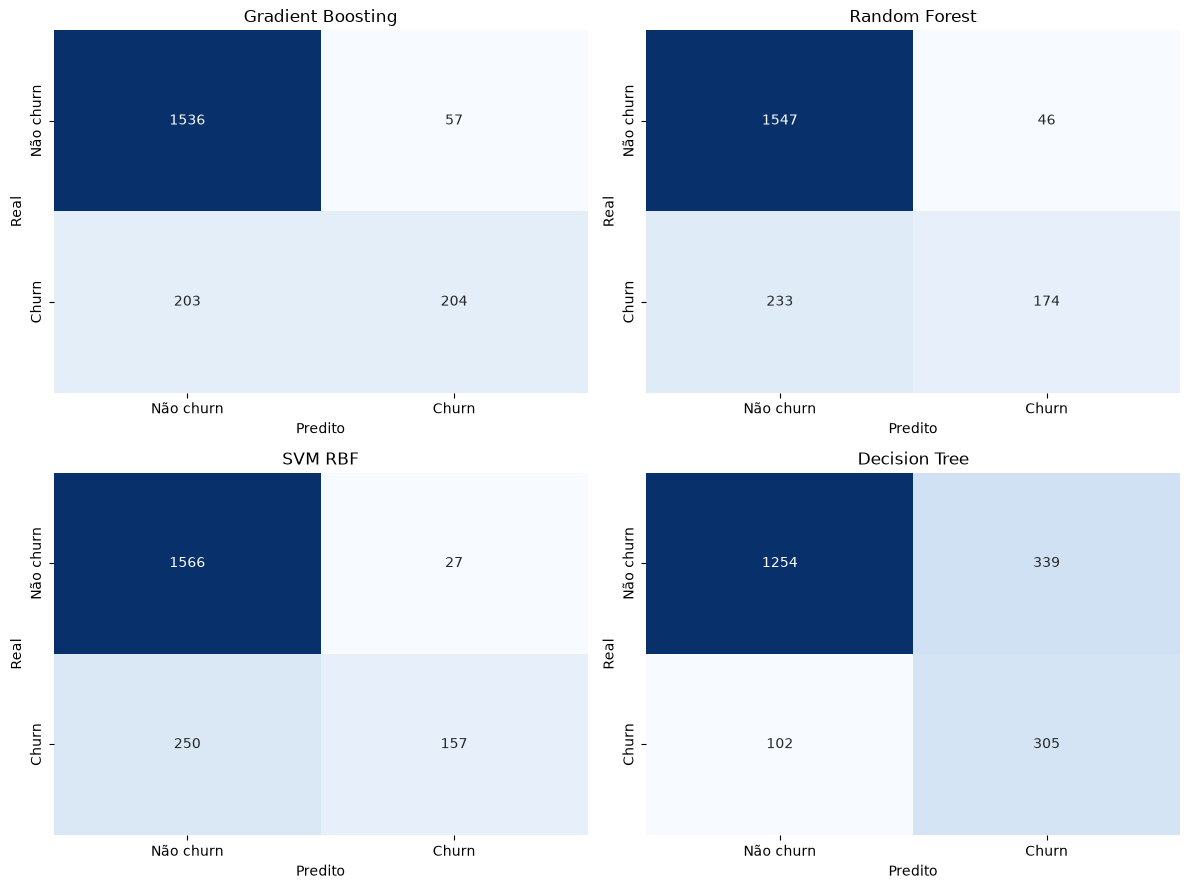

In [17]:
model_order = test_results_df["Model"].tolist()
n_models = len(model_order)
n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 4.5 * n_rows),
)

axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, model_name in zip(axes, model_order):
    matrix = confusion_matrix(
        Y_test,
        test_predictions[model_name],
        labels=[0, 1],
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Não churn", "Churn"],
        yticklabels=["Não churn", "Churn"],
        ax=ax,
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()


## Curvas ROC

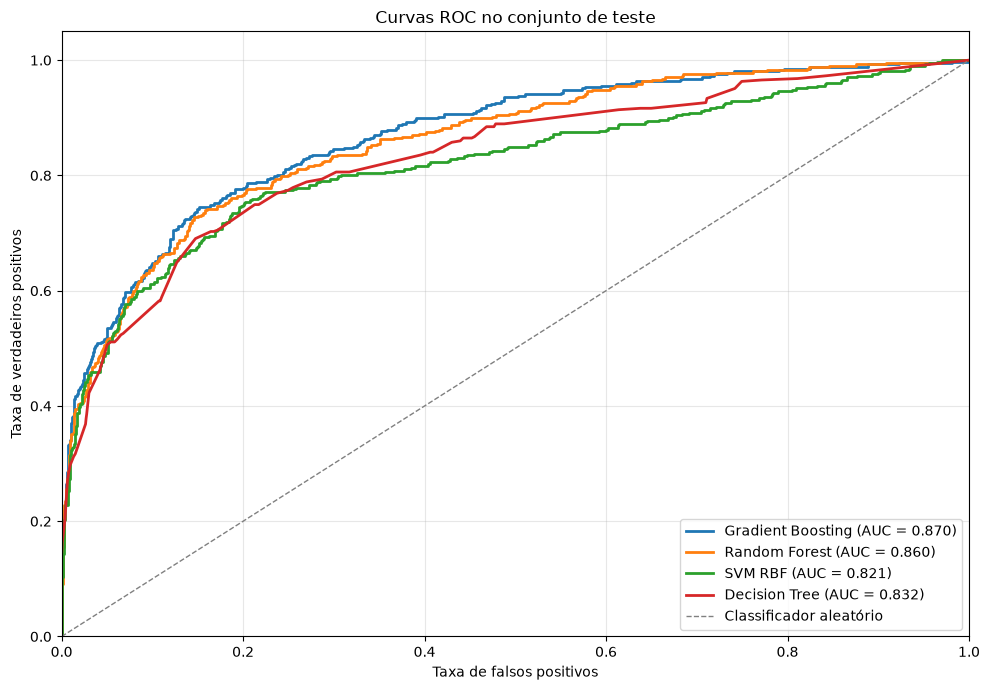

In [18]:
plt.figure(figsize=(10, 7))

for model_name in test_results_df["Model"]:
    fpr, tpr, _ = roc_curve(
        Y_test,
        test_scores[model_name],
    )
    auc = roc_auc_score(
        Y_test,
        test_scores[model_name],
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc:.3f})",
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1,
    label="Classificador aleatório",
)

plt.title("Curvas ROC no conjunto de teste")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()


## Curvas Precision–Recall

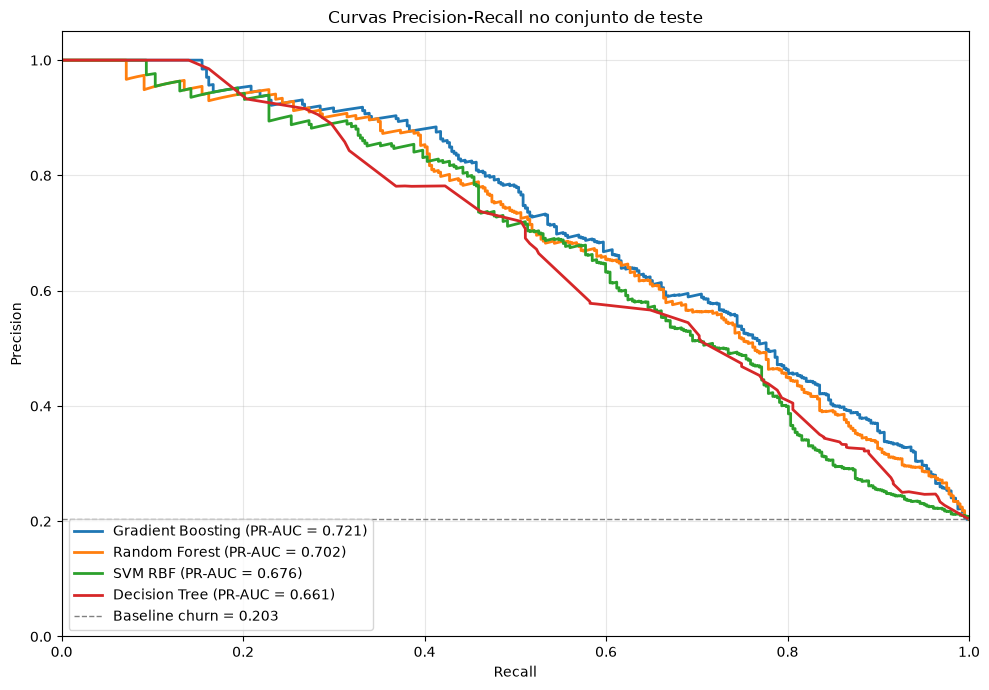

In [19]:
plt.figure(figsize=(10, 7))

baseline_precision = Y_test.mean()

for model_name in test_results_df["Model"]:
    precision, recall, _ = precision_recall_curve(
        Y_test,
        test_scores[model_name],
    )
    pr_auc = average_precision_score(
        Y_test,
        test_scores[model_name],
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_name} (PR-AUC = {pr_auc:.3f})",
    )

plt.axhline(
    baseline_precision,
    linestyle="--",
    color="gray",
    linewidth=1,
    label=f"Baseline churn = {baseline_precision:.3f}",
)

plt.title("Curvas Precision-Recall no conjunto de teste")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()


# Análise do comportamento dos modelos

Até este ponto, os modelos foram avaliados por métricas tradicionais de desempenho, como Accuracy, Precision, Recall, F1-score, ROC-AUC e PR-AUC.

Embora essas métricas permitam comparar a qualidade global dos classificadores, elas não explicam quais perfis de clientes são corretamente identificados por cada modelo nem quais permanecem fora das regiões de decisão aprendidas.

Assim, esta seção apresenta uma análise complementar baseada na sobreposição dos verdadeiros positivos dos modelos, buscando responder às seguintes questões:

* Quais clientes são identificados simultaneamente pelos modelos?
* Quais clientes são identificados exclusivamente por cada algoritmo?
* Quais clientes não são identificados por nenhum modelo?
* Que características diferenciam esses grupos?

Essa análise permite compreender não apenas qual modelo apresenta melhor desempenho, mas também como cada algoritmo representa o fenômeno de churn.

## Sobreposição dos churners identificados


In [20]:
prediction_comparison = pd.DataFrame(
    {
        "Actual": Y_test,
        **{
            model_name: pd.Series(
                predictions,
                index=Y_test.index,
            )
            for model_name, predictions
            in test_predictions.items()
        },
    },
    index=Y_test.index,
)

In [21]:
actual_churners = prediction_comparison[
    prediction_comparison["Actual"] == 1
].copy()


Quantos churners cada modelo identificou?

In [22]:
churn_hits = (
    actual_churners
    .drop(columns="Actual")
    .sum()
    .sort_values(ascending=False)
    .rename("Churners Identified")
    .to_frame()
)

display(churn_hits)

,Churners Identified
Decision Tree,305
Gradient Boosting,204
Random Forest,174
SVM RBF,157


Churners encontrados apenas pela Decision Tree

In [23]:
other_models = [
    "Gradient Boosting",
    "Random Forest",
    "SVM RBF",
]

tree_unique_churners = actual_churners[
    (actual_churners["Decision Tree"] == 1)
    & (actual_churners[other_models].sum(axis=1) == 0)
]

len(tree_unique_churners)

103

Churners identificados pela árvore e perdidos pelo Gradient Boosting

In [24]:
tree_hits_missed_by_gb = actual_churners[
    (actual_churners["Decision Tree"] == 1)
    & (actual_churners["Gradient Boosting"] == 0)
]

len(tree_hits_missed_by_gb)

105

Churners identificados por todos

In [25]:
model_columns = list(best_models.keys())

churners_identified_by_all = actual_churners[
    actual_churners[model_columns].eq(1).all(axis=1)
]

len(churners_identified_by_all)

147

Churners perdidos por todos

In [26]:
churners_missed_by_all = actual_churners[
    actual_churners[model_columns].eq(0).all(axis=1)
]

len(churners_missed_by_all)

97

In [27]:
pairwise_complementarity = []

for model_a in model_columns:
    for model_b in model_columns:
        if model_a >= model_b:
            continue

        a_hits_b_misses = (
            (actual_churners[model_a] == 1)
            & (actual_churners[model_b] == 0)
        ).sum()

        b_hits_a_misses = (
            (actual_churners[model_b] == 1)
            & (actual_churners[model_a] == 0)
        ).sum()

        both_hit = (
            (actual_churners[model_a] == 1)
            & (actual_churners[model_b] == 1)
        ).sum()

        pairwise_complementarity.append({
            "Model A": model_a,
            "Model B": model_b,
            "Both Identify": both_hit,
            "A Identifies / B Misses": a_hits_b_misses,
            "B Identifies / A Misses": b_hits_a_misses,
        })

pairwise_complementarity_df = pd.DataFrame(
    pairwise_complementarity
)

display(pairwise_complementarity_df)

,Model A,Model B,Both Identify,A Identifies / B Misses,B Identifies / A Misses
0,Gradient Boosting,Random Forest,172,32,2
1,Gradient Boosting,SVM RBF,156,48,1
2,Random Forest,SVM RBF,147,27,10
3,Decision Tree,Gradient Boosting,200,105,4
4,Decision Tree,Random Forest,174,131,0
5,Decision Tree,SVM RBF,155,150,2


               Decision Tree
          +----------------------+
          |                      |
          |    105 exclusivos    |
          |                      |
          |    +-----------+     |
          |    | GB        |     |
          |    | 200       |     |
          |    +-----------+     |
          |                      |
          +----------------------+

##  Discussão dos perfis operacionais

### Síntese dos resultados

Os resultados demonstraram que os modelos apresentaram perfis operacionais distintos na identificação de clientes propensos ao churn. Enquanto Gradient Boosting, Random Forest e SVM priorizaram maior precisão em detrimento do recall, a Decision Tree adotou um comportamento significativamente mais sensível à classe positiva, identificando aproximadamente três quartos dos clientes que efetivamente abandonaram o banco.

### Trade-off entre precisão e recall

O Gradient Boosting apresentou o melhor equilíbrio geral, alcançando PR-AUC de 0,721, recall de aproximadamente 50% e precisão superior a 78%. Em contraste, a Decision Tree elevou o recall para cerca de 75%, porém com redução da precisão para aproximadamente 47%, refletindo aumento expressivo do número de falsos positivos.

### A descoberta científica do notebook

* 97 churners não foram identificados por nenhum modelo;
* 147 foram identificados por todos;
* Decision Tree encontrou 105 churners que o Gradient Boosting não encontrou;
* Gradient Boosting encontrou apenas 4 churners exclusivos.

A análise de sobreposição revelou que os modelos não aprenderam exatamente a mesma fronteira de decisão. Gradient Boosting, Random Forest e SVM apresentaram elevado grau de concordância entre si, enquanto a Decision Tree identificou um conjunto expressivo de clientes não detectados pelos demais modelos. Em particular, foram identificados 105 clientes corretamente classificados apenas pela Decision Tree em relação ao Gradient Boosting, enquanto apenas quatro clientes foram identificados exclusivamente pelo Gradient Boosting

### O insight

Esses resultados sugerem que a Decision Tree explora regiões distintas do espaço de atributos, capturando padrões de churn diferentes daqueles aprendidos pelos demais algoritmos. Embora apresente maior taxa de falsos positivos, a sua elevada sensibilidade indica potencial complementaridade em relação aos modelos mais conservadores.

### A consequência

Os resultados obtidos motivam a investigação de estratégias de combinação entre modelos. Como os algoritmos demonstraram capturar subconjuntos parcialmente distintos de clientes propensos ao churn, abordagens baseadas em ensembles podem explorar essa complementaridade, aumentando a cobertura da classe positiva sem necessariamente reproduzir o comportamento individual de cada modelo.


## Fechamento Testes Modelos

Apesar do bom desempenho do Gradient Boosting em termos de equilíbrio entre precisão e recall, observa-se que aproximadamente metade dos clientes que efetivamente abandonaram o banco permaneceu sem identificação. Esse resultado sugere que parte da limitação pode estar associada não apenas ao algoritmo utilizado, mas também ao conjunto de atributos disponível na base de dados. Informações comportamentais, temporais ou transacionais, ausentes neste estudo, possivelmente permitiriam uma separação mais eficaz entre clientes que permanecem e clientes que abandonam o serviço.

## Análise exploratória de ensembles

A análise de complementaridade entre os modelos revelou que a Decision Tree identificou um número expressivo de clientes propensos ao churn que não foram detectados pelos demais algoritmos. Essa evidência motivou uma análise exploratória para investigar se estratégias simples de combinação poderiam aumentar a cobertura da classe positiva. Ressalta-se que essa etapa não fez parte do processo de seleção dos modelos e tem caráter exclusivamente exploratório.

#### Ensemble OR entre Gradient Boosting e Decision Tree

In [28]:
gb_pred = test_predictions["Gradient Boosting"]
dt_pred = test_predictions["Decision Tree"]

ensemble_or_pred = (
    (gb_pred == 1) |
    (dt_pred == 1)
).astype(int)

In [29]:
tn, fp, fn, tp = confusion_matrix(
    Y_test,
    ensemble_or_pred,
).ravel()

In [30]:
ensemble_or_metrics = {
    "Model": "Ensemble OR — GB + DT",
    "Accuracy": accuracy_score(Y_test, ensemble_or_pred),
    "Balanced Accuracy": balanced_accuracy_score(
        Y_test,
        ensemble_or_pred,
    ),
    "Precision": precision_score(
        Y_test,
        ensemble_or_pred,
        zero_division=0,
    ),
    "Recall": recall_score(
        Y_test,
        ensemble_or_pred,
        zero_division=0,
    ),
    "F1": f1_score(
        Y_test,
        ensemble_or_pred,
        zero_division=0,
    ),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "Predicted Churn": int(ensemble_or_pred.sum()),
}

In [31]:
pd.DataFrame([ensemble_or_metrics])

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,TN,FP,FN,TP,Predicted Churn
0,Ensemble OR — GB + DT,0.781,0.77289,0.476117,0.759214,0.585227,1253,340,98,309,649


Embora a análise de complementaridade tenha demonstrado que a Decision Tree identifica clientes distintos daqueles encontrados pelo Gradient Boosting, a estratégia de combinação por operador lógico OR apresentou ganho marginal, aumentando o recall de 74,9% para 75,9%, ao custo de apenas um falso positivo adicional. Esses resultados indicam que, sob essa estratégia de combinação, a maior parte da capacidade preditiva já estava concentrada na Decision Tree.

Quem são os 105 clientes exclusivos da Decision Tree?

In [32]:
continuous_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "EstimatedSalary",
]

categorical_features = [
    "Gender",
    "Geography",
    "ProductsGroup",
    "HasCrCard",
    "IsActiveMember",
]

In [33]:
actual_churners = X_test.loc[
    Y_test == 1
]

shared_true_positives = X_test.loc[
    (Y_test == 1) &
    (gb_pred == 1) &
    (dt_pred == 1)
]

dt_exclusive = X_test.loc[
    (Y_test == 1) &
    (dt_pred == 1) &
    (gb_pred == 0)
]

gb_exclusive = X_test.loc[
    (Y_test == 1) &
    (gb_pred == 1) &
    (dt_pred == 0)
]

missed_by_both = X_test.loc[
    (Y_test == 1) &
    (gb_pred == 0) &
    (dt_pred == 0)
]
comparison_numeric = pd.DataFrame({
    "All Churners": actual_churners.describe().loc["mean"],
    "Share Churners: ": shared_true_positives.describe().loc["mean"],
    "GB TP": gb_exclusive.describe().loc["mean"],
    "DT Exclusive": dt_exclusive.describe().loc["mean"],
    "Missing By Both": missed_by_both.describe().loc["mean"],
})
comparison_numeric

,All Churners,Share Churners:,GB TP,DT Exclusive,Missing By Both
CreditScore,649.719902,645.79500,518.0000,656.466667,655.877551
Age,45.066339,48.95000,46.5000,43.209524,39.071429
Tenure,4.651106,4.63500,1.2500,4.685714,4.785714
Balance,90192.458993,93909.35760,27774.7125,88451.709619,87019.703367
NumOfProducts,1.508600,1.70500,1.5000,1.104762,1.540816
HasCrCard,0.712531,0.69500,1.0000,0.742857,0.704082
IsActiveMember,0.346437,0.23000,0.5000,0.523810,0.387755
EstimatedSalary,99217.724988,101644.63885,97572.8975,95375.385238,98448.767959


In [34]:
group_sizes = pd.Series({
    "All churners": len(actual_churners),
    "Shared TP": len(shared_true_positives),
    "DT exclusive": len(dt_exclusive),
    "GB exclusive": len(gb_exclusive),
    "Missed by both": len(missed_by_both),
})

group_sizes

All churners      407
Shared TP         200
DT exclusive      105
GB exclusive        4
Missed by both     98
dtype: int64

In [35]:
assert (
    len(shared_true_positives)
    + len(dt_exclusive)
    + len(gb_exclusive)
    + len(missed_by_both)
    == len(actual_churners)
)

In [36]:
comparison_gender = pd.DataFrame({
    "All Churners": actual_churners['Gender'].value_counts(normalize=True),
    "Share Churners: ": shared_true_positives['Gender'].value_counts(normalize=True),
    "GB TP": gb_exclusive['Gender'].value_counts(normalize=True) ,
    "DT Exclusive": dt_exclusive['Gender'].value_counts(normalize=True)  ,
    "Missing By Both": missed_by_both['Gender'].value_counts(normalize=True),
})
comparison_gender

,All Churners,Share Churners:,GB TP,DT Exclusive,Missing By Both
Gender,,,,,
Female,0.572482,0.61,0.75,0.495238,0.571429
Male,0.427518,0.39,0.25,0.504762,0.428571


In [37]:
comparison_ProductsGroup = pd.DataFrame({
    "All Churners": actual_churners['ProductsGroup'].value_counts(normalize=True),
    "Share Churners: ": shared_true_positives['ProductsGroup'].value_counts(normalize=True),
    "GB TP": gb_exclusive['ProductsGroup'].value_counts(normalize=True) ,
    "DT Exclusive": dt_exclusive['ProductsGroup'].value_counts(normalize=True)  ,
    "Missing By Both": missed_by_both['ProductsGroup'].value_counts(normalize=True),
})
comparison_ProductsGroup

,All Churners,Share Churners:,GB TP,DT Exclusive,Missing By Both
ProductsGroup,,,,,
1,0.663391,0.645,0.5,0.895238,0.459184
2,0.189189,0.055,0.5,0.104762,0.540816
3+,0.147420,0.300,0.0,0.000000,0.000000


In [38]:
comparison_IsActiveMember = pd.DataFrame({
    "All Churners": actual_churners['IsActiveMember'].value_counts(normalize=True),
    "Share Churners: ": shared_true_positives['IsActiveMember'].value_counts(normalize=True),
    "GB TP": gb_exclusive['IsActiveMember'].value_counts(normalize=True) ,
    "DT Exclusive": dt_exclusive['IsActiveMember'].value_counts(normalize=True)  ,
    "Missing By Both": missed_by_both['IsActiveMember'].value_counts(normalize=True),
})
comparison_IsActiveMember

,All Churners,Share Churners:,GB TP,DT Exclusive,Missing By Both
IsActiveMember,,,,,
0,0.653563,0.77,0.5,0.47619,0.612245
1,0.346437,0.23,0.5,0.52381,0.387755


In [39]:
comparison_HasCrCard = pd.DataFrame({
    "All Churners": actual_churners['HasCrCard'].value_counts(normalize=True),
    "Share Churners: ": shared_true_positives['HasCrCard'].value_counts(normalize=True),
    "GB TP": gb_exclusive['HasCrCard'].value_counts(normalize=True) ,
    "DT Exclusive": dt_exclusive['HasCrCard'].value_counts(normalize=True)  ,
    "Missing By Both": missed_by_both['HasCrCard'].value_counts(normalize=True),
})
comparison_HasCrCard

,All Churners,Share Churners:,GB TP,DT Exclusive,Missing By Both
HasCrCard,,,,,
0,0.287469,0.305,NaN,0.257143,0.295918
1,0.712531,0.695,1.0,0.742857,0.704082


#### Shared TP versus DT Exclusive

In [40]:
group_a = shared_true_positives
group_b = dt_exclusive

In [41]:
comparison_1_numeric = pd.DataFrame({
    "Shared TP Count": group_a[continuous_features].count(),
    "Shared TP Mean": group_a[continuous_features].mean(),
    "Shared TP Median": group_a[continuous_features].median(),
    "Shared TP Std": group_a[continuous_features].std(),
    "Shared TP IQR": (
        group_a[continuous_features].quantile(0.75)
        - group_a[continuous_features].quantile(0.25)
    ),
    "Shared TP Min": group_a[continuous_features].min(),
    "Shared TP Max": group_a[continuous_features].max(),
    "Shared TP Range": (
        group_a[continuous_features].max()
        - group_a[continuous_features].min()
    ),
    "DT Exclusive Count": group_b[continuous_features].count(),
    "DT Exclusive Mean": group_b[continuous_features].mean(),
    "DT Exclusive Median": group_b[continuous_features].median(),
    "DT Exclusive Std": group_b[continuous_features].std(),
    "DT Exclusive IQR": (
        group_b[continuous_features].quantile(0.75)
        - group_b[continuous_features].quantile(0.25)
    ),
    "DT Exclusive Min": group_b[continuous_features].min(),
    "DT Exclusive Max": group_b[continuous_features].max(),
    "DT Exclusive Range": (
        group_b[continuous_features].max()
        - group_b[continuous_features].min()
    ),
})

comparison_1_numeric["Mean Difference"] = (
    comparison_1_numeric["DT Exclusive Mean"]
    - comparison_1_numeric["Shared TP Mean"]
)

comparison_1_numeric["Median Difference"] = (
    comparison_1_numeric["DT Exclusive Median"]
    - comparison_1_numeric["Shared TP Median"]
)

comparison_1_numeric.round(2)

,Shared TP Count,Shared TP Mean,Shared TP Median,Shared TP Std,Shared TP IQR,Shared TP Min,Shared TP Max,Shared TP Range,DT Exclusive Count,DT Exclusive Mean,DT Exclusive Median,DT Exclusive Std,DT Exclusive IQR,DT Exclusive Min,DT Exclusive Max,DT Exclusive Range,Mean Difference,Median Difference
CreditScore,200,645.79,642.5,101.86,138.75,351.00,850.00,499.00,105,656.47,655.00,97.44,129.00,434.00,850.00,416.00,10.67,12.50
Age,200,48.95,48.5,7.44,8.00,22.00,70.00,48.00,105,43.21,43.00,7.76,9.00,24.00,65.00,41.00,-5.74,-5.50
Tenure,200,4.64,4.0,2.72,5.00,0.00,10.00,10.00,105,4.69,5.00,3.08,6.00,0.00,10.00,10.00,0.05,1.00
Balance,200,93909.36,109589.0,57644.17,69561.90,0.00,250898.09,250898.09,105,88451.71,110148.49,61899.42,133903.12,0.00,194532.66,194532.66,-5457.65,559.50
EstimatedSalary,200,101644.64,97106.9,59672.85,106936.45,236.45,198810.65,198574.20,105,95375.39,92920.04,55410.81,92645.99,667.66,199378.58,198710.92,-6269.25,-4186.87


Binary variables comparison

In [42]:
binary_features = [
    "HasCrCard",
    "IsActiveMember",
]

comparison_1_binary = pd.DataFrame({
    "Shared TP Count": group_a[binary_features].count(),
    "Shared TP Share 1": group_a[binary_features].mean(),
    "Shared TP Count 0": group_a[binary_features].count() - group_a[binary_features].sum(),
    "Shared TP Share 0": 1 - group_a[binary_features].mean(),
    "DT Exclusive Count": group_b[binary_features].count(),
    "DT Exclusive Count 1": group_b[binary_features].sum(),
    "DT Exclusive Share 1": group_b[binary_features].mean(),
    "DT Exclusive Count 0": group_b[binary_features].count() - group_b[binary_features].sum(),
    "DT Exclusive Share 0": 1 - group_b[binary_features].mean(),
})

comparison_1_binary["Share 1 Difference"] = (
    comparison_1_binary["DT Exclusive Share 1"]
    - comparison_1_binary["Shared TP Share 1"]
)

comparison_1_binary["Share 0 Difference"] = (
    comparison_1_binary["DT Exclusive Share 0"]
    - comparison_1_binary["Shared TP Share 0"]
)

comparison_1_binary.round(4)

,Shared TP Count,Shared TP Share 1,Shared TP Count 0,Shared TP Share 0,DT Exclusive Count,DT Exclusive Count 1,DT Exclusive Share 1,DT Exclusive Count 0,DT Exclusive Share 0,Share 1 Difference,Share 0 Difference
HasCrCard,200,0.695,61,0.305,105,78,0.7429,27,0.2571,0.0479,-0.0479
IsActiveMember,200,0.230,154,0.770,105,55,0.5238,50,0.4762,0.2938,-0.2938


In [43]:
binary_share_by_value = pd.concat(
    {
        "Shared TP": group_a[binary_features].apply(
            lambda column: column.value_counts(normalize=True)
        ).T,
        "DT Exclusive": group_b[binary_features].apply(
            lambda column: column.value_counts(normalize=True)
        ).T,
    },
    axis=1,
).fillna(0)

binary_share_by_value.round(4)

Shared TP        DT Exclusive        
                       0      1            1       0
HasCrCard          0.305  0.695       0.7429  0.2571
IsActiveMember     0.770  0.230       0.5238  0.4762

In [44]:
comparison_1_tests = []

for feature in continuous_features:
    shared_values = group_a[feature].dropna()
    dt_values = group_b[feature].dropna()

    statistic, p_value = mannwhitneyu(
        shared_values,
        dt_values,
        alternative="two-sided",
    )

    n_shared = len(shared_values)
    n_dt = len(dt_values)

    rank_biserial = (
        2 * statistic / (n_shared * n_dt)
    ) - 1

    comparison_1_tests.append({
        "Feature": feature,
        "Shared TP Median": shared_values.median(),
        "DT Exclusive Median": dt_values.median(),
        "Median Difference": (
            dt_values.median()
            - shared_values.median()
        ),
        "Mann-Whitney U": statistic,
        "p-value": p_value,
        "Rank-Biserial Correlation": rank_biserial,
    })

comparison_1_tests = pd.DataFrame(comparison_1_tests)

comparison_1_tests

,Feature,Shared TP Median,DT Exclusive Median,Median Difference,Mann-Whitney U,p-value,Rank-Biserial Correlation
0,CreditScore,642.500,655.00,12.500,10017.0,5.096580e-01,-0.046000
1,Age,48.500,43.00,-5.500,15197.0,1.330503e-10,0.447333
2,Tenure,4.000,5.00,1.000,10457.0,9.534234e-01,-0.004095
3,Balance,109588.995,110148.49,559.495,10627.0,8.617350e-01,0.012095
4,EstimatedSalary,97106.905,92920.04,-4186.865,11113.0,4.025916e-01,0.058381


In [45]:
binary_comparison_data = pd.concat(
    [
        group_a.assign(Group="Shared TP"),
        group_b.assign(Group="DT Exclusive"),
    ],
    axis=0,
)

comparison_1_binary_tests = []

for feature in binary_features:
    contingency_table = pd.crosstab(
        binary_comparison_data["Group"],
        binary_comparison_data[feature],
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    comparison_1_binary_tests.append({
        "Feature": feature,
        "Chi-square": chi2,
        "p-value": p_value,
        "Shared TP Share 1": group_a[feature].mean(),
        "DT Exclusive Share 1": group_b[feature].mean(),
        "Difference": (
            group_b[feature].mean()
            - group_a[feature].mean()
        ),
    })

comparison_1_binary_tests = pd.DataFrame(
    comparison_1_binary_tests
)

comparison_1_binary_tests

,Feature,Chi-square,p-value,Shared TP Share 1,DT Exclusive Share 1,Difference
0,HasCrCard,0.552748,4.571972e-01,0.695,0.742857,0.047857
1,IsActiveMember,25.524733,4.367483e-07,0.230,0.523810,0.293810


In [46]:
def categorical_proportions(
    group_a,
    group_b,
    feature,
):
    return pd.concat(
        {
            "Shared TP": (
                group_a[feature]
                .value_counts(normalize=True)
            ),
            "DT Exclusive": (
                group_b[feature]
                .value_counts(normalize=True)
            ),
        },
        axis=1,
    ).fillna(0)

In [47]:

for c in categorical_features:
   print( categorical_proportions(
    group_a,
    group_b,
    c,
))

        Shared TP  DT Exclusive
Gender                         
Female       0.61      0.495238
Male         0.39      0.504762
           Shared TP  DT Exclusive
Geography                         
Germany        0.460      0.352381
France         0.365      0.419048
Spain          0.175      0.228571
               Shared TP  DT Exclusive
ProductsGroup                         
1                  0.645      0.895238
3+                 0.300      0.000000
2                  0.055      0.104762
           Shared TP  DT Exclusive
HasCrCard                         
1              0.695      0.742857
0              0.305      0.257143
                Shared TP  DT Exclusive
IsActiveMember                         
0                    0.77       0.47619
1                    0.23       0.52381


In [48]:
categorical_tests = []

comparison_data = pd.concat(
    [
        group_a.assign(Group="Shared TP"),
        group_b.assign(Group="DT Exclusive"),
    ],
    axis=0,
)

for feature in categorical_features:
    contingency_table = pd.crosstab(
        comparison_data["Group"],
        comparison_data[feature],
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    categorical_tests.append({
        "Feature": feature,
        "Chi-square": chi2,
        "Degrees of Freedom": dof,
        "p-value": p_value,
    })

categorical_tests = pd.DataFrame(categorical_tests)

categorical_tests

,Feature,Chi-square,Degrees of Freedom,p-value
0,Gender,3.247248,1,7.154346e-02
1,Geography,3.431216,2,1.798543e-01
2,ProductsGroup,39.760557,2,2.323297e-09
3,HasCrCard,0.552748,1,4.571972e-01
4,IsActiveMember,25.524733,1,4.367483e-07


In [49]:
contingency_table = pd.crosstab(
    comparison_data["Group"],
    comparison_data["ProductsGroup"],
)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns,
)

ProductsGroup,1,2,3+
Group,,,
DT Exclusive,76.770492,7.57377,20.655738
Shared TP,146.229508,14.42623,39.344262


A comparação entre os churners identificados simultaneamente pela Decision Tree e pelo Gradient Boosting (Shared TP) e aqueles identificados exclusivamente pela Decision Tree (DT Exclusive) revelou diferenças relevantes em idade, número de produtos e nível de atividade. Os clientes do grupo DT Exclusive apresentaram idade inferior e forte concentração na categoria de um único produto, correspondente a aproximadamente 89,5% do grupo. Em contraste, 30% dos clientes do grupo Shared TP possuíam três ou mais produtos, categoria ausente entre os exclusivos da Decision Tree. A distribuição de ProductsGroup apresentou associação estatisticamente significativa com os grupos analisados (χ² = 39,76; p < 0,001).

Também foi observada diferença significativa no nível de atividade (χ² = 25,52; p < 0,001). Enquanto 77% dos clientes do grupo Shared TP eram inativos, 52,4% dos churners exclusivos da Decision Tree ainda eram clientes ativos. Esses resultados indicam que os dois modelos reconhecem com maior facilidade um perfil mais evidente de churn, composto por clientes mais velhos e inativos, enquanto a Decision Tree amplia a identificação para clientes mais jovens, ativos e concentrados na posse de apenas um produto.

Não foram encontradas diferenças estatisticamente significativas para gênero, localização geográfica ou posse de cartão de crédito. Embora o grupo Shared TP tenha apresentado maior proporção de mulheres e clientes da Alemanha, essas variações não forneceram evidências suficientes para caracterizar perfis distintos.

A Decision Tree não está simplesmente encontrando mais clientes aleatoriamente. Ela parece ter aprendido um segmento específico de churners que o Gradient Boosting tende a deixar abaixo do limiar de classificação: clientes mais jovens, ainda ativos e, principalmente, com apenas um produto.

#### Comparação 2 — Churners detectados versus churners não detectados

Nesta etapa, investigamos as características dos clientes que realizaram churn, mas não foram identificados nem pelo Gradient Boosting nem pela Decision Tree.

O objetivo é identificar possíveis regiões de baixa sensibilidade compartilhadas pelos dois modelos, isto é, perfis de clientes que representam uma zona cega do sistema preditivo.

Inicialmente, os clientes não identificados são comparados descritivamente com o conjunto completo de churners. Entretanto, como o grupo `Missed by Both` está contido no conjunto `All Churners`, esses grupos não são independentes.

Por esse motivo, os testes estatísticos são realizados entre:

- `Detected by Any`: churners identificados por pelo menos um dos dois modelos;
- `Missed by Both`: churners não identificados por nenhum dos modelos.

Essa divisão produz grupos mutuamente exclusivos e permite uma comparação estatística metodologicamente mais adequada.

In [50]:
# Churners identificados por pelo menos um dos dois modelos.
#
# O operador "|" representa a condição lógica OR:
# basta que um dos modelos tenha previsto churn.
detected_by_any = X_test.loc[
    (Y_test == 1)
    & (
        (gb_pred == 1)
        | (dt_pred == 1)
    )
].copy()



In [51]:
group_sizes_comparison_2 = pd.Series({
    "All Churners": len(actual_churners),
    "Detected by Any": len(detected_by_any),
    "Missed by Both": len(missed_by_both),
})

group_sizes_comparison_2

All Churners       407
Detected by Any    309
Missed by Both      98
dtype: int64

In [52]:
ensemble_coverage_summary_df = pd.DataFrame([
    {
        "Modelo / estratégia": "Gradient Boosting",
        "Tipo": "Modelo individual",
        "Churners corretamente identificados": int(
            ((Y_test == 1) & (gb_pred == 1)).sum()
        ),
        "Churners não identificados": int(
            ((Y_test == 1) & (gb_pred == 0)).sum()
        ),
        "Clientes previstos como churn": int(gb_pred.sum()),
        "Falsos positivos": int(
            ((Y_test == 0) & (gb_pred == 1)).sum()
        ),
        "Precision": precision_score(
            Y_test,
            gb_pred,
            zero_division=0,
        ),
        "Cobertura da classe positiva": recall_score(
            Y_test,
            gb_pred,
            zero_division=0,
        ),
    },
    {
        "Modelo / estratégia": "Decision Tree",
        "Tipo": "Modelo individual",
        "Churners corretamente identificados": int(
            ((Y_test == 1) & (dt_pred == 1)).sum()
        ),
        "Churners não identificados": int(
            ((Y_test == 1) & (dt_pred == 0)).sum()
        ),
        "Clientes previstos como churn": int(dt_pred.sum()),
        "Falsos positivos": int(
            ((Y_test == 0) & (dt_pred == 1)).sum()
        ),
        "Precision": precision_score(
            Y_test,
            dt_pred,
            zero_division=0,
        ),
        "Cobertura da classe positiva": recall_score(
            Y_test,
            dt_pred,
            zero_division=0,
        ),
    },
    {
        "Modelo / estratégia": "União OR — GB + DT",
        "Tipo": "Combinação exploratória",
        "Churners corretamente identificados": int(
            ((Y_test == 1) & (ensemble_or_pred == 1)).sum()
        ),
        "Churners não identificados": int(
            ((Y_test == 1) & (ensemble_or_pred == 0)).sum()
        ),
        "Clientes previstos como churn": int(ensemble_or_pred.sum()),
        "Falsos positivos": int(
            ((Y_test == 0) & (ensemble_or_pred == 1)).sum()
        ),
        "Precision": precision_score(
            Y_test,
            ensemble_or_pred,
            zero_division=0,
        ),
        "Cobertura da classe positiva": recall_score(
            Y_test,
            ensemble_or_pred,
            zero_division=0,
        ),
    },
])

best_individual_coverage = ensemble_coverage_summary_df.loc[
    ensemble_coverage_summary_df["Tipo"] == "Modelo individual",
    "Cobertura da classe positiva",
].max()

ensemble_coverage_summary_df[
    "Ganho de cobertura vs melhor individual (p.p.)"
] = (
    (
        ensemble_coverage_summary_df["Cobertura da classe positiva"]
        - best_individual_coverage
    )
    * 100
).round(2)

ensemble_coverage_summary_df[
    [
        "Precision",
        "Cobertura da classe positiva",
    ]
] = ensemble_coverage_summary_df[
    [
        "Precision",
        "Cobertura da classe positiva",
    ]
].round(4)

ensemble_coverage_summary_df

,Modelo / estratégia,Tipo,Churners corretamente identificados,Churners não identificados,Clientes previstos como churn,Falsos positivos,Precision,Cobertura da classe positiva,Ganho de cobertura vs melhor individual (p.p.)
0,Gradient Boosting,Modelo individual,204,203,261,57,0.7816,0.5012,-24.82
1,Decision Tree,Modelo individual,305,102,644,339,0.4736,0.7494,0.00
2,União OR — GB + DT,Combinação exploratória,309,98,649,340,0.4761,0.7592,0.98


In [53]:
# Os churners detectados e os churners não detectados devem,
# juntos, corresponder a todos os churners do conjunto de teste.

assert (
    len(detected_by_any)
    + len(missed_by_both)
    == len(actual_churners)
), "A divisão dos churners apresenta inconsistência."

In [54]:
assert detected_by_any.index.intersection(
    missed_by_both.index
).empty, "Os grupos possuem clientes em comum."

##### Comparação descritiva com todos os churners

A tabela abaixo utiliza o conjunto completo de churners como referência descritiva.

Essa comparação ajuda a verificar se os clientes não identificados se afastam do perfil médio geral de churn. Entretanto, não serão aplicados testes estatísticos entre `All Churners` e `Missed by Both`, porque o segundo grupo está contido no primeiro.

In [55]:
comparison_2_descriptive_numeric = pd.DataFrame({
    "All Churners Mean": (
        actual_churners[continuous_features].mean()
    ),
    "All Churners Median": (
        actual_churners[continuous_features].median()
    ),
    "Missed by Both Mean": (
        missed_by_both[continuous_features].mean()
    ),
    "Missed by Both Median": (
        missed_by_both[continuous_features].median()
    ),
})

comparison_2_descriptive_numeric["Mean Difference"] = (
    comparison_2_descriptive_numeric["Missed by Both Mean"]
    - comparison_2_descriptive_numeric["All Churners Mean"]
)

comparison_2_descriptive_numeric["Median Difference"] = (
    comparison_2_descriptive_numeric["Missed by Both Median"]
    - comparison_2_descriptive_numeric["All Churners Median"]
)

comparison_2_descriptive_numeric.round(3)

,All Churners Mean,All Churners Median,Missed by Both Mean,Missed by Both Median,Mean Difference,Median Difference
CreditScore,649.720,650.00,655.878,652.500,6.158,2.500
Age,45.066,45.00,39.071,37.500,-5.995,-7.500
Tenure,4.651,5.00,4.786,5.000,0.135,0.000
Balance,90192.459,109705.52,87019.703,108618.880,-3172.756,-1086.640
EstimatedSalary,99217.725,93132.61,98448.768,88503.455,-768.957,-4629.155


In [56]:
comparison_2_numeric = pd.DataFrame({
    "Detected Mean": (
        detected_by_any[continuous_features].mean()
    ),
    "Detected Median": (
        detected_by_any[continuous_features].median()
    ),
    "Detected Std": (
        detected_by_any[continuous_features].std()
    ),
    "Missed Mean": (
        missed_by_both[continuous_features].mean()
    ),
    "Missed Median": (
        missed_by_both[continuous_features].median()
    ),
    "Missed Std": (
        missed_by_both[continuous_features].std()
    ),
})

comparison_2_numeric["Mean Difference"] = (
    comparison_2_numeric["Missed Mean"]
    - comparison_2_numeric["Detected Mean"]
)

comparison_2_numeric["Median Difference"] = (
    comparison_2_numeric["Missed Median"]
    - comparison_2_numeric["Detected Median"]
)

comparison_2_numeric.round(3)

,Detected Mean,Detected Median,Detected Std,Missed Mean,Missed Median,Missed Std,Mean Difference,Median Difference
CreditScore,647.767,648.00,102.088,655.878,652.500,91.942,8.111,4.500
Age,46.968,47.00,8.025,39.071,37.500,11.255,-7.896,-9.500
Tenure,4.608,4.00,2.859,4.786,5.000,2.672,0.177,1.000
Balance,91198.705,109876.82,59416.445,87019.703,108618.880,64210.697,-4179.002,-1257.940
EstimatedSalary,99461.601,93739.71,58231.055,98448.768,88503.455,56615.828,-1012.833,-5236.255


##### Teste de Mann–Whitney

Para comparar as variáveis numéricas, utiliza-se o teste não paramétrico de Mann–Whitney.

Esse teste verifica se os valores observados em dois grupos independentes apresentam distribuições diferentes, sem exigir normalidade.

As hipóteses são:

- **H0:** as distribuições da variável são equivalentes entre os grupos;
- **H1:** as distribuições da variável diferem entre os grupos.

Adota-se nível de significância de 5%.

In [57]:

comparison_2_numeric_tests = []

for feature in continuous_features:
    detected_values = (
        detected_by_any[feature]
        .dropna()
    )

    missed_values = (
        missed_by_both[feature]
        .dropna()
    )

    statistic, p_value = mannwhitneyu(
        detected_values,
        missed_values,
        alternative="two-sided",
    )

    n_detected = len(detected_values)
    n_missed = len(missed_values)

    # Correlação bisserial por postos.
    #
    # A direção foi organizada para facilitar a leitura:
    # valor positivo -> valores tendem a ser maiores em Detected by Any
    # valor negativo -> valores tendem a ser maiores em Missed by Both
    rank_biserial = (
        2 * statistic / (n_detected * n_missed)
    ) - 1

    comparison_2_numeric_tests.append({
        "Feature": feature,
        "Detected Median": detected_values.median(),
        "Missed Median": missed_values.median(),
        "Median Difference": (
            missed_values.median()
            - detected_values.median()
        ),
        "Mann-Whitney U": statistic,
        "p-value": p_value,
        "Rank-Biserial Correlation": rank_biserial,
    })

comparison_2_numeric_tests = pd.DataFrame(
    comparison_2_numeric_tests
)

comparison_2_numeric_tests

,Feature,Detected Median,Missed Median,Median Difference,Mann-Whitney U,p-value,Rank-Biserial Correlation
0,CreditScore,648.00,652.500,4.500,14487.0,5.195400e-01,-0.043194
1,Age,47.00,37.500,-9.500,22949.0,1.371492e-14,0.515686
2,Tenure,4.00,5.000,1.000,14466.0,5.039728e-01,-0.044581
3,Balance,109876.82,108618.880,-1257.940,15326.0,8.544023e-01,0.012218
4,EstimatedSalary,93739.71,88503.455,-5236.255,15393.0,8.042428e-01,0.016644


In [58]:
def classify_rank_biserial(effect_size):
    """
    Classifica a magnitude da correlação bisserial por postos.

    A classificação considera o valor absoluto,
    pois o sinal representa apenas a direção da diferença.
    """
    absolute_effect = abs(effect_size)

    if absolute_effect < 0.10:
        return "Negligible"

    if absolute_effect < 0.30:
        return "Small"

    if absolute_effect < 0.50:
        return "Moderate"

    return "Large"

In [59]:
comparison_2_numeric_tests["Effect Size"] = (
    comparison_2_numeric_tests[
        "Rank-Biserial Correlation"
    ].apply(classify_rank_biserial)
)

comparison_2_numeric_tests["Statistically Significant"] = (
    comparison_2_numeric_tests["p-value"] < 0.05
)

comparison_2_numeric_tests.sort_values(
    by="p-value"
)

,Feature,Detected Median,Missed Median,Median Difference,Mann-Whitney U,p-value,Rank-Biserial Correlation,Effect Size,Statistically Significant
1,Age,47.00,37.500,-9.500,22949.0,1.371492e-14,0.515686,Large,True
2,Tenure,4.00,5.000,1.000,14466.0,5.039728e-01,-0.044581,Negligible,False
0,CreditScore,648.00,652.500,4.500,14487.0,5.195400e-01,-0.043194,Negligible,False
4,EstimatedSalary,93739.71,88503.455,-5236.255,15393.0,8.042428e-01,0.016644,Negligible,False
3,Balance,109876.82,108618.880,-1257.940,15326.0,8.544023e-01,0.012218,Negligible,False


In [60]:
def compare_categorical_proportions(
    group_a,
    group_b,
    feature,
    group_a_name="Detected by Any",
    group_b_name="Missed by Both",
):
    """
    Compara a distribuição proporcional de uma variável categórica
    entre dois grupos.

    Cada coluna soma aproximadamente 1.
    """

    comparison = pd.concat(
        {
            group_a_name: (
                group_a[feature]
                .value_counts(normalize=True)
            ),
            group_b_name: (
                group_b[feature]
                .value_counts(normalize=True)
            ),
        },
        axis=1,
    )

    return comparison.fillna(0)

In [61]:
comparison_2_gender = compare_categorical_proportions(
    detected_by_any,
    missed_by_both,
    "Gender",
)

comparison_2_gender

,Detected by Any,Missed by Both
Gender,,
Female,0.572816,0.571429
Male,0.427184,0.428571


In [62]:
comparison_2_geography = compare_categorical_proportions(
    detected_by_any,
    missed_by_both,
    "Geography",
)

comparison_2_geography

,Detected by Any,Missed by Both
Geography,,
Germany,0.417476,0.224490
France,0.385113,0.571429
Spain,0.197411,0.204082


In [63]:
comparison_2_products = compare_categorical_proportions(
    detected_by_any,
    missed_by_both,
    "ProductsGroup",
)

comparison_2_products

,Detected by Any,Missed by Both
ProductsGroup,,
1,0.728155,0.459184
3+,0.194175,0.000000
2,0.077670,0.540816


In [64]:
comparison_2_credit_card = compare_categorical_proportions(
    detected_by_any,
    missed_by_both,
    "HasCrCard",
)

comparison_2_credit_card

,Detected by Any,Missed by Both
HasCrCard,,
1,0.71521,0.704082
0,0.28479,0.295918


In [65]:
comparison_2_active_member = compare_categorical_proportions(
    detected_by_any,
    missed_by_both,
    "IsActiveMember",
)

comparison_2_active_member

,Detected by Any,Missed by Both
IsActiveMember,,
0,0.666667,0.612245
1,0.333333,0.387755


##### Teste qui-quadrado de independência

Para as variáveis categóricas, utiliza-se o teste qui-quadrado de independência.

As hipóteses são:

- **H0:** a distribuição da variável categórica é independente do grupo de detecção;
- **H1:** existe associação entre a variável categórica e o grupo de detecção.

Um resultado significativo indica que a distribuição das categorias difere entre os churners detectados e os churners não detectados.

In [66]:

comparison_2_data = pd.concat(
    [
        detected_by_any.assign(
            DetectionGroup="Detected by Any"
        ),
        missed_by_both.assign(
            DetectionGroup="Missed by Both"
        ),
    ],
    axis=0,
)

comparison_2_categorical_tests = []

for feature in categorical_features:
    contingency_table = pd.crosstab(
        comparison_2_data["DetectionGroup"],
        comparison_2_data[feature],
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    expected_df = pd.DataFrame(
        expected,
        index=contingency_table.index,
        columns=contingency_table.columns,
    )

    comparison_2_categorical_tests.append({
        "Feature": feature,
        "Chi-square": chi2,
        "Degrees of Freedom": dof,
        "p-value": p_value,
        "Minimum Expected Frequency": (
            expected_df.min().min()
        ),
    })

comparison_2_categorical_tests = pd.DataFrame(
    comparison_2_categorical_tests
)

comparison_2_categorical_tests[
    "Statistically Significant"
] = (
    comparison_2_categorical_tests["p-value"] < 0.05
)

comparison_2_categorical_tests.sort_values(
    by="p-value"
)

,Feature,Chi-square,Degrees of Freedom,p-value,Minimum Expected Frequency,Statistically Significant
2,ProductsGroup,111.501918,2,6.132905e-25,14.447174,True
1,Geography,13.492380,2,1.175349e-03,19.503686,True
4,IsActiveMember,0.747729,1,3.871962e-01,33.950860,False
3,HasCrCard,0.007060,1,9.330387e-01,28.171990,False
0,Gender,0.000000,1,1.000000e+00,41.896806,False


In [67]:
def cramers_v(contingency_table):
    """
    Calcula o V de Cramér para uma tabela de contingência.

    O resultado varia entre 0 e 1:

    0 -> ausência de associação
    1 -> associação máxima
    """

    chi2, _, _, _ = chi2_contingency(
        contingency_table
    )

    n = contingency_table.to_numpy().sum()

    rows, columns = contingency_table.shape

    denominator = min(
        rows - 1,
        columns - 1,
    )

    if denominator == 0:
        return np.nan

    return np.sqrt(
        chi2 / (n * denominator)
    )

In [68]:
def classify_cramers_v(effect_size):
    """
    Classificação exploratória da magnitude do V de Cramér.
    """

    if pd.isna(effect_size):
        return "Not available"

    if effect_size < 0.10:
        return "Negligible"

    if effect_size < 0.30:
        return "Small"

    if effect_size < 0.50:
        return "Moderate"

    return "Large"

In [69]:
comparison_2_categorical_tests = []

for feature in categorical_features:
    contingency_table = pd.crosstab(
        comparison_2_data["DetectionGroup"],
        comparison_2_data[feature],
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    expected_df = pd.DataFrame(
        expected,
        index=contingency_table.index,
        columns=contingency_table.columns,
    )

    effect_size = cramers_v(
        contingency_table
    )

    comparison_2_categorical_tests.append({
        "Feature": feature,
        "Chi-square": chi2,
        "Degrees of Freedom": dof,
        "p-value": p_value,
        "Cramer's V": effect_size,
        "Effect Size": classify_cramers_v(
            effect_size
        ),
        "Minimum Expected Frequency": (
            expected_df.min().min()
        ),
    })

comparison_2_categorical_tests = pd.DataFrame(
    comparison_2_categorical_tests
)

comparison_2_categorical_tests[
    "Statistically Significant"
] = (
    comparison_2_categorical_tests["p-value"] < 0.05
)

comparison_2_categorical_tests.sort_values(
    by="p-value"
)

,Feature,Chi-square,Degrees of Freedom,p-value,Cramer's V,Effect Size,Minimum Expected Frequency,Statistically Significant
2,ProductsGroup,111.501918,2,6.132905e-25,0.523412,Large,14.447174,True
1,Geography,13.492380,2,1.175349e-03,0.182074,Small,19.503686,True
4,IsActiveMember,0.747729,1,3.871962e-01,0.042862,Negligible,33.950860,False
3,HasCrCard,0.007060,1,9.330387e-01,0.004165,Negligible,28.171990,False
0,Gender,0.000000,1,1.000000e+00,0.000000,Negligible,41.896806,False


In [70]:
comparison_2_proportions = {}

for feature in categorical_features:
    comparison_2_proportions[feature] = (
        compare_categorical_proportions(
            detected_by_any,
            missed_by_both,
            feature,
        )
    )

In [71]:
for feature, comparison in (
    comparison_2_proportions.items()
):
    print(f"\nFeature: {feature}")
    display(comparison)


Feature: Gender


,Detected by Any,Missed by Both
Gender,,
Female,0.572816,0.571429
Male,0.427184,0.428571



Feature: Geography


,Detected by Any,Missed by Both
Geography,,
Germany,0.417476,0.224490
France,0.385113,0.571429
Spain,0.197411,0.204082



Feature: ProductsGroup


,Detected by Any,Missed by Both
ProductsGroup,,
1,0.728155,0.459184
3+,0.194175,0.000000
2,0.077670,0.540816



Feature: HasCrCard


,Detected by Any,Missed by Both
HasCrCard,,
1,0.71521,0.704082
0,0.28479,0.295918



Feature: IsActiveMember


,Detected by Any,Missed by Both
IsActiveMember,,
0,0.666667,0.612245
1,0.333333,0.387755


In [72]:
comparison_2_plot_data = pd.concat(
    [
        detected_by_any.assign(
            DetectionGroup="Detected by Any"
        ),
        missed_by_both.assign(
            DetectionGroup="Missed by Both"
        ),
    ],
    axis=0,
)

<Figure size 800x500 with 0 Axes>

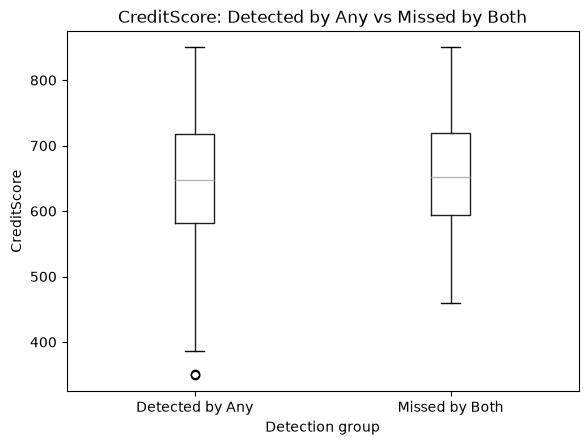

<Figure size 800x500 with 0 Axes>

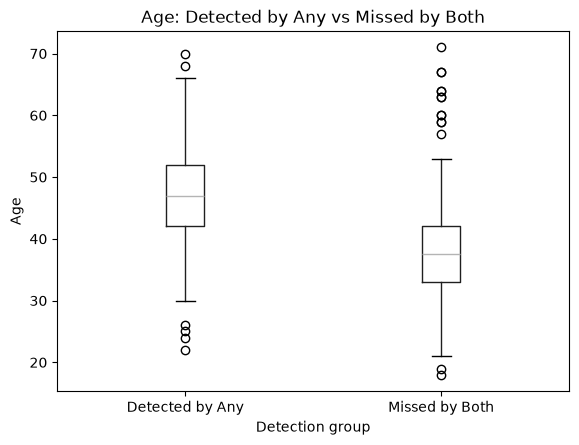

<Figure size 800x500 with 0 Axes>

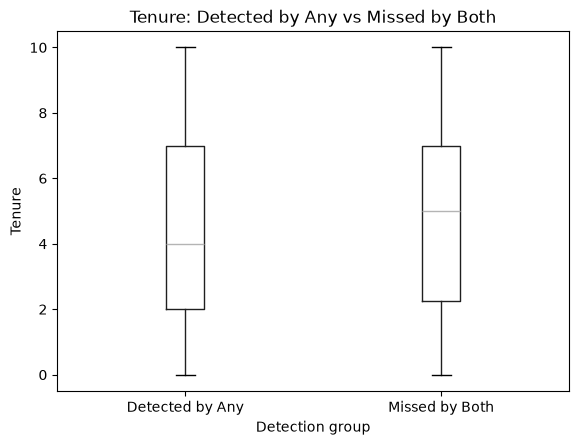

<Figure size 800x500 with 0 Axes>

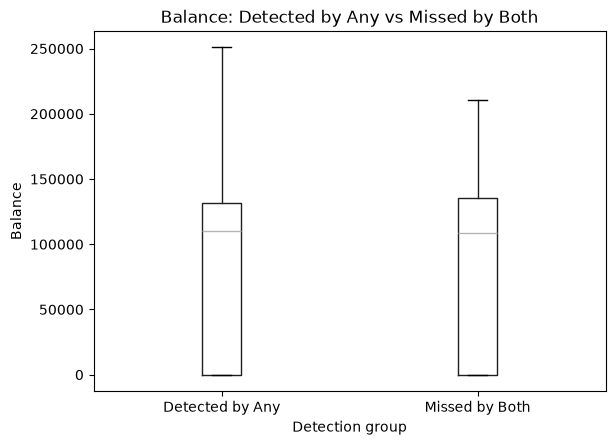

<Figure size 800x500 with 0 Axes>

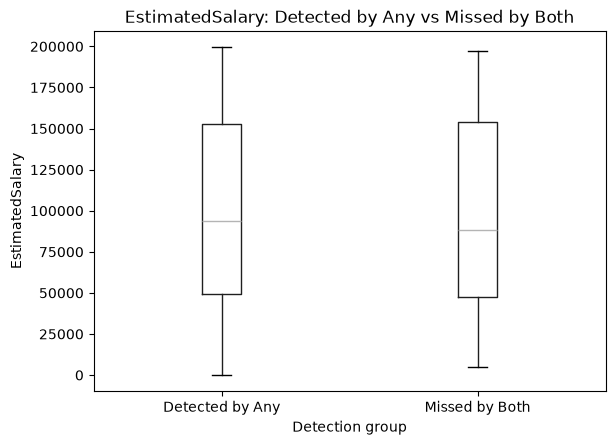

In [73]:
for feature in continuous_features:
    plt.figure(figsize=(8, 5))

    comparison_2_plot_data.boxplot(
        column=feature,
        by="DetectionGroup",
        grid=False,
    )

    plt.title(
        f"{feature}: Detected by Any vs Missed by Both"
    )

    plt.suptitle("")

    plt.xlabel("Detection group")
    plt.ylabel(feature)

    plt.show()

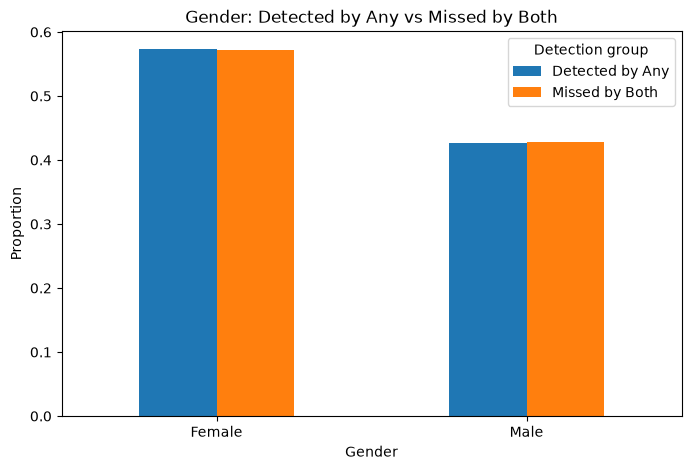

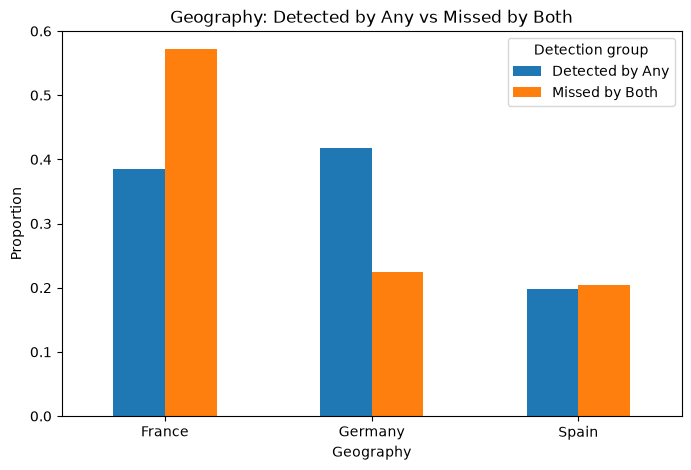

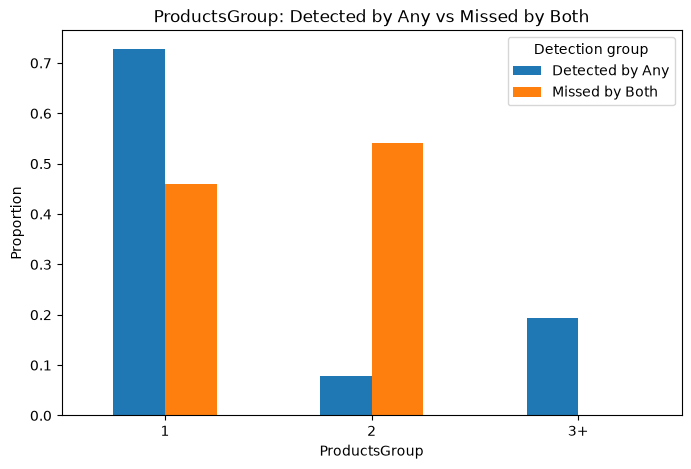

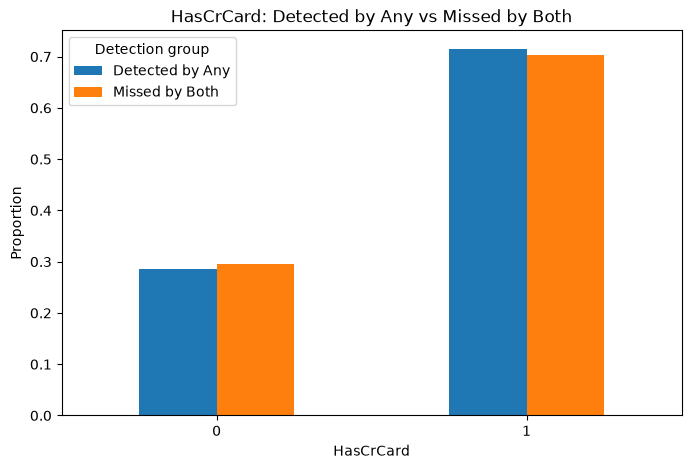

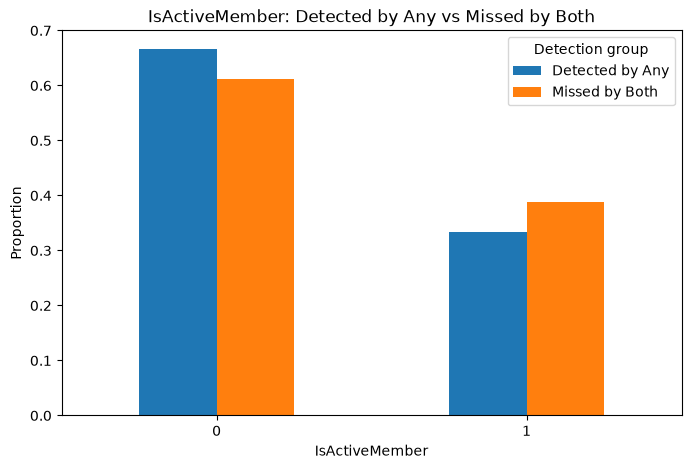

In [74]:
for feature in categorical_features:
    proportions = (
        comparison_2_plot_data
        .groupby("DetectionGroup")[feature]
        .value_counts(normalize=True)
        .rename("Proportion")
        .reset_index()
    )

    pivot_table = proportions.pivot(
        index=feature,
        columns="DetectionGroup",
        values="Proportion",
    ).fillna(0)

    pivot_table.plot(
        kind="bar",
        figsize=(8, 5),
    )

    plt.title(
        f"{feature}: Detected by Any vs Missed by Both"
    )

    plt.xlabel(feature)
    plt.ylabel("Proportion")

    plt.xticks(rotation=0)
    plt.legend(title="Detection group")

    plt.show()

In [75]:
significant_numeric_comparison_2 = (
    comparison_2_numeric_tests.loc[
        comparison_2_numeric_tests[
            "p-value"
        ] < 0.05
    ]
    .sort_values("p-value")
)

significant_numeric_comparison_2

,Feature,Detected Median,Missed Median,Median Difference,Mann-Whitney U,p-value,Rank-Biserial Correlation,Effect Size,Statistically Significant
1,Age,47.0,37.5,-9.5,22949.0,1.371492e-14,0.515686,Large,True


In [76]:
significant_categorical_comparison_2 = (
    comparison_2_categorical_tests.loc[
        comparison_2_categorical_tests[
            "p-value"
        ] < 0.05
    ]
    .sort_values("p-value")
)

significant_categorical_comparison_2

,Feature,Chi-square,Degrees of Freedom,p-value,Cramer's V,Effect Size,Minimum Expected Frequency,Statistically Significant
2,ProductsGroup,111.501918,2,6.132905e-25,0.523412,Large,14.447174,True
1,Geography,13.492380,2,1.175349e-03,0.182074,Small,19.503686,True


### Síntese da comparação

A comparação entre os churners identificados por pelo menos um dos modelos e aqueles não identificados por nenhum deles revelou uma zona cega compartilhada principalmente associada à idade, ao número de produtos e à localização geográfica.

Entre as variáveis numéricas, apenas `Age` apresentou diferença estatisticamente significativa. Os churners detectados possuíam mediana de 47 anos, enquanto os não detectados apresentaram mediana de 37,5 anos, correspondendo a uma diferença de 9,5 anos. O teste de Mann–Whitney confirmou essa diferença (p < 0,001), com tamanho de efeito elevado, medido pela correlação bisserial por postos (r = 0,516). Esse resultado indica que os dois modelos apresentam maior dificuldade para identificar churn entre clientes relativamente mais jovens.

Entre as variáveis categóricas, `ProductsGroup` apresentou a associação mais intensa com o grupo de detecção (χ² = 111,50; p < 0,001; V de Cramér = 0,523). Os churners não identificados concentraram-se principalmente entre clientes com dois produtos, enquanto os clientes com três ou mais produtos foram integralmente identificados por pelo menos um dos modelos. Esse comportamento sugere que a posse de dois produtos atua como um sinal contrário ao churn dentro das fronteiras aprendidas pelos algoritmos, levando parte desses clientes a permanecer abaixo do limiar de classificação.

A variável `Geography` também apresentou associação estatisticamente significativa com o grupo de detecção (χ² = 13,49; p = 0,001), embora com pequeno tamanho de efeito (V de Cramér = 0,182). Os clientes não identificados apresentaram maior concentração na França e menor participação da Alemanha. Não foram observadas diferenças relevantes para `CreditScore`, `Tenure`, `Balance`, `EstimatedSalary`, `Gender`, `HasCrCard` ou `IsActiveMember`.

Os resultados indicam que a zona cega compartilhada pelos modelos é composta predominantemente por clientes mais jovens, com dois produtos e maior concentração geográfica na França. Esse perfil representa uma região de menor sensibilidade do sistema preditivo e deve ser considerado na análise de limiares, na explicabilidade das previsões e na eventual construção de alertas complementares na aplicação final.

### Comparação 3 — Casos exclusivos do Gradient Boosting

Ao analisar a sobreposição entre os verdadeiros positivos da Decision Tree e do Gradient Boosting, observou-se que apenas quatro clientes foram corretamente classificados exclusivamente pelo Gradient Boosting.

Em virtude desse reduzido número de observações, optou-se por não realizar testes estatísticos inferenciais, uma vez que não haveria poder estatístico suficiente para suportar generalizações.

Assim, esta seção apresenta apenas uma análise descritiva desses clientes, com o objetivo de compreender quais características podem ter contribuído para que fossem corretamente identificados apenas pelo Gradient Boosting.

In [77]:
print(f"Quantidade de clientes exclusivos do Gradient Boosting: {len(gb_exclusive)}")

Quantidade de clientes exclusivos do Gradient Boosting: 4


In [78]:
gb_exclusive

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,ProductsGroup
8097,626,France,Female,52,0,0.00,2,1,0,32159.46,2
4911,407,Spain,Male,37,1,0.00,1,1,1,49161.12,1
9624,350,France,Female,40,0,111098.85,1,1,1,172321.21,1
4648,689,Spain,Female,57,4,0.00,2,1,0,136649.80,2


In [79]:
gb_probability = pd.Series(
    test_scores["Gradient Boosting"],
    index=X_test.index,
    name="GB Probability",
)

dt_probability = pd.Series(
    test_scores["Decision Tree"],
    index=X_test.index,
    name="DT Probability",
)

In [80]:
gb_exclusive = gb_exclusive.copy()

gb_exclusive["GB Probability"] = gb_probability.loc[
    gb_exclusive.index
]

gb_exclusive["DT Probability"] = dt_probability.loc[
    gb_exclusive.index
]

gb_exclusive.sort_values(
    by="GB Probability",
    ascending=False,
)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,ProductsGroup,GB Probability,DT Probability
9624,350,France,Female,40,0,111098.85,1,1,1,172321.21,1,0.624978,0.363581
8097,626,France,Female,52,0,0.00,2,1,0,32159.46,2,0.512281,0.240619
4648,689,Spain,Female,57,4,0.00,2,1,0,136649.80,2,0.508200,0.240619
4911,407,Spain,Male,37,1,0.00,1,1,1,49161.12,1,0.506396,0.477163


In [81]:
comparison_gb_exclusive = pd.DataFrame({

    "All Churners Mean":
        actual_churners[
            continuous_features
        ].mean(),

    "GB Exclusive":
        gb_exclusive[
            continuous_features
        ].mean()

})

comparison_gb_exclusive["Difference"] = (

    comparison_gb_exclusive["GB Exclusive"]

    -

    comparison_gb_exclusive["All Churners Mean"]

)

comparison_gb_exclusive.round(2)

,All Churners Mean,GB Exclusive,Difference
CreditScore,649.72,518.00,-131.72
Age,45.07,46.50,1.43
Tenure,4.65,1.25,-3.40
Balance,90192.46,27774.71,-62417.75
EstimatedSalary,99217.72,97572.90,-1644.83


In [82]:
for feature in categorical_features:

    print(f"\n{feature}")

    display(

        pd.DataFrame({

            "Count":
                gb_exclusive[feature].value_counts(),

            "Proportion":
                gb_exclusive[feature].value_counts(
                    normalize=True
                )

        })

    )


Gender


,Count,Proportion
Gender,,
Female,3,0.75
Male,1,0.25



Geography


,Count,Proportion
Geography,,
France,2,0.5
Spain,2,0.5



ProductsGroup


,Count,Proportion
ProductsGroup,,
1,2,0.5
2,2,0.5
3+,0,0.0



HasCrCard


,Count,Proportion
HasCrCard,,
1,4,1.0



IsActiveMember


,Count,Proportion
IsActiveMember,,
0,2,0.5
1,2,0.5


In [83]:
comparison = pd.concat([

    actual_churners.assign(Group="All Churners"),

    gb_exclusive.assign(Group="GB Exclusive")

])

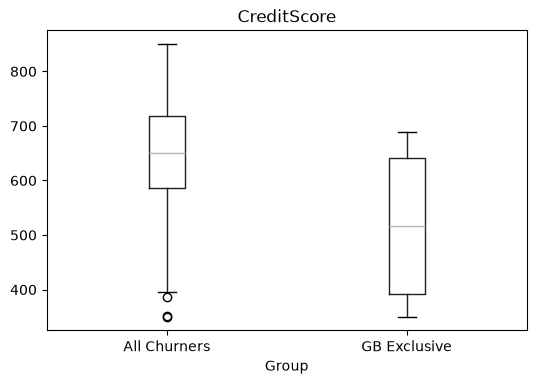

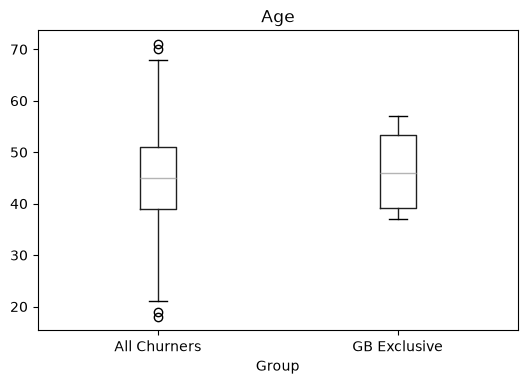

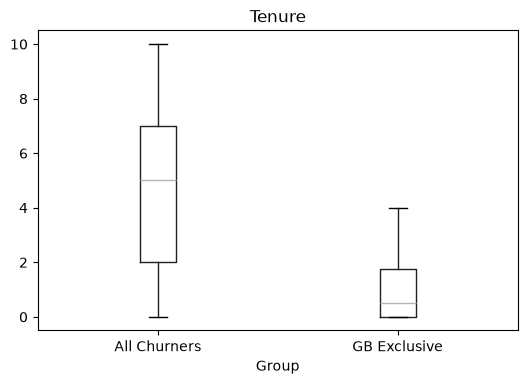

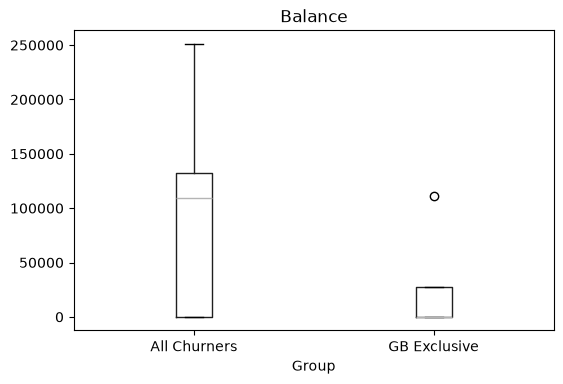

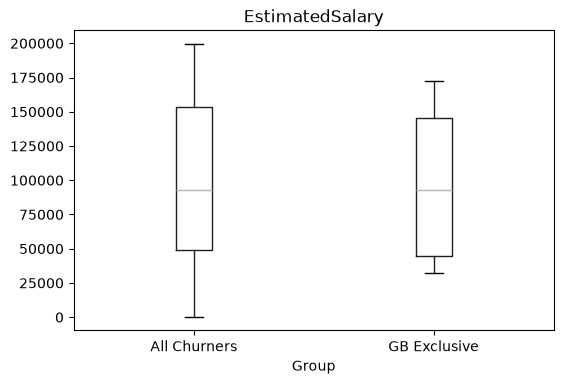

In [84]:
for feature in continuous_features:

    comparison.boxplot(

        column=feature,

        by="Group",

        grid=False,

        figsize=(6,4)

    )

    plt.title(feature)

    plt.suptitle("")

    plt.show()

## Lições aprendidas sobre o comportamento dos modelos

| Região         | O que aprendemos                                                                                                                                                                    |
| -------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Shared TP      | Churn clássico; ambos reconhecem facilmente.                                                                                                                                        |
| DT Exclusive   | A árvore amplia a cobertura para clientes mais jovens, ativos e com um produto.                                                                                                     |
| Missed by Both | Zona cega composta principalmente por clientes mais jovens, com dois produtos e maior concentração na França.                                                                       |
| GB Exclusive   | Casos pontuais que sugerem melhor ajuste local do Gradient Boosting em combinações específicas de atributos, sem evidência suficiente para caracterizar um novo perfil de clientes. |


# Exportação dos Modelos

O Gradient Boosting será utilizado como modelo principal de risco, enquanto a Decision Tree atuará como modelo complementar de sensibilidade. A aplicação não utilizará diretamente uma regra OR para emitir uma decisão binária final. Em vez disso, a concordância ou divergência entre os classificadores será transformada em quatro níveis de risco, preservando a capacidade de generalização do Gradient Boosting e aproveitando a maior cobertura da classe positiva apresentada pela Decision Tree.

Nesta etapa, os pipelines finais do Gradient Boosting e da Decision Tree são persistidos para utilização na aplicação. Os artefatos incluem tanto os classificadores ajustados quanto as transformações de pré-processamento, garantindo consistência entre treinamento e inferência.

In [85]:
def calculate_model_metrics(
    y_true,
    prediction,
    probability,
) -> dict:
    return {
        "test_accuracy": float(
            accuracy_score(y_true, prediction)
        ),
        "test_precision": float(
            precision_score(
                y_true,
                prediction,
                zero_division=0,
            )
        ),
        "test_recall": float(
            recall_score(
                y_true,
                prediction,
                zero_division=0,
            )
        ),
        "test_roc_auc": float(
            roc_auc_score(y_true, probability)
        ),
        "test_pr_auc": float(
            average_precision_score(
                y_true,
                probability,
            )
        ),
    }

In [86]:
gb_pipeline = best_models["Gradient Boosting"]
dt_pipeline = best_models["Decision Tree"]

In [87]:

check_is_fitted(gb_pipeline)
check_is_fitted(dt_pipeline)

In [88]:

ARTIFACTS_DIR = Path("../artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

GB_ARTIFACT_PATH = ARTIFACTS_DIR / "gradient_boosting_pipeline.joblib"
joblib.dump(
    gb_pipeline,
    GB_ARTIFACT_PATH,
    compress=3,
)

DT_ARTIFACT_PATH = ARTIFACTS_DIR / "decision_tree_pipeline.joblib"
joblib.dump(
    dt_pipeline,
    DT_ARTIFACT_PATH,
    compress=3,
)

['../artifacts/decision_tree_pipeline.joblib']

Gerar metadados de controle de qualidade

In [89]:

def calculate_sha256(path: Path) -> str:
    digest = hashlib.sha256()

    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(8192), b""):
            digest.update(chunk)

    return digest.hexdigest()

In [90]:
gb_metrics = calculate_model_metrics(
    Y_test,
    gb_pred,
    gb_pipeline.predict_proba(X_test)[:, 1],
)

dt_metrics = calculate_model_metrics(
    Y_test,
    dt_pred,
    dt_pipeline.predict_proba(X_test)[:, 1],
)
metadata = {
    "project": "bank-customer-churn",
    "artifact_version": "1.0.0",
    "exported_at_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": platform.python_version(),
    "scikit_learn_version": sklearn.__version__,
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "joblib_version": joblib.__version__,
    "target": "Exited",
    "positive_class": 1,
    "models": {
        "gradient_boosting": {
            "file": "gradient_boosting_pipeline.joblib",
            "role": "primary",
            **gb_metrics,
        },
        "decision_tree": {
            "file": "decision_tree_pipeline.joblib",
            "role": "sensitivity_complement",
            **dt_metrics,
        },
    },
    "decision_policy": {
        "gb_0_dt_0": "low",
        "gb_0_dt_1": "attention",
        "gb_1_dt_0": "high",
        "gb_1_dt_1": "critical",
    },
}

input_schema = {
    "feature_names": X_train.columns.tolist(),
    "feature_count": X_train.shape[1],
    "dtypes": {
        column: str(dtype)
        for column, dtype in X_train.dtypes.items()
    },
}

metadata["models"]["gradient_boosting"]["sha256"] = calculate_sha256(
    GB_ARTIFACT_PATH
)

metadata["models"]["decision_tree"]["sha256"] = calculate_sha256(
    DT_ARTIFACT_PATH
)

metadata["input_schema"] = input_schema

with open(
    ARTIFACTS_DIR / "metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(metadata, file, indent=2, ensure_ascii=False)

Validar integridade dos modelos exportados

In [91]:
gb_pipeline_loaded = joblib.load(
    GB_ARTIFACT_PATH
)

dt_pipeline_loaded = joblib.load(
    DT_ARTIFACT_PATH
)

gb_pred_loaded = gb_pipeline_loaded.predict(X_test)
dt_pred_loaded = dt_pipeline_loaded.predict(X_test)

In [92]:

assert np.array_equal(gb_pred, gb_pred_loaded)
assert np.array_equal(dt_pred, dt_pred_loaded)

print("Artefatos exportados e validados com sucesso.")

Artefatos exportados e validados com sucesso.


In [93]:
gb_proba_original = gb_pipeline.predict_proba(X_test)[:, 1]
gb_proba_loaded = gb_pipeline_loaded.predict_proba(X_test)[:, 1]

dt_proba_original = dt_pipeline.predict_proba(X_test)[:, 1]
dt_proba_loaded = dt_pipeline_loaded.predict_proba(X_test)[:, 1]

np.testing.assert_allclose(
    gb_proba_original,
    gb_proba_loaded,
    rtol=1e-12,
    atol=1e-12,
)

np.testing.assert_allclose(
    dt_proba_original,
    dt_proba_loaded,
    rtol=1e-12,
    atol=1e-12,
)

print(
    "Predições e probabilidades preservadas "
    "após a serialização."
)

Predições e probabilidades preservadas após a serialização.


Criar casos de referência

In [94]:
reference_candidates = X_test.copy().reset_index(names="source_index")

reference_candidates["expected_gb_prediction"] = gb_pred
reference_candidates["expected_dt_prediction"] = dt_pred

reference_candidates["decision_case"] = (
    "gb_"
    + reference_candidates[
        "expected_gb_prediction"
    ].astype(str)
    + "_dt_"
    + reference_candidates[
        "expected_dt_prediction"
    ].astype(str)
)

reference_sample = (
    reference_candidates
    .groupby(
        "decision_case",
        group_keys=False,
    )
    .head(10)
    .copy()
)

reference_sample["expected_gb_probability"] = (
    gb_pipeline.predict_proba(
        reference_sample[X_test.columns]
    )[:, 1]
)

reference_sample["expected_dt_probability"] = (
    dt_pipeline.predict_proba(
        reference_sample[X_test.columns]
    )[:, 1]
)

reference_sample.to_csv(
    ARTIFACTS_DIR / "reference_predictions.csv",
    index=False,
)

# Conclusão